<a href="https://colab.research.google.com/github/Wendell9/N1_IA/blob/main/Modelo_N1_1%C2%BABIMESTRE_ipynb_json.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

N1 - Inteligência Artificial

Regressão Linear

Nomes:

[Colocar nome e RA dos integrantes do grupo]

*Orientações:*

Esse arquivo contem o modelo esperado de respostas para a N1. Podem ser acrescentadas algumas outras informações ou trechos com códigos, entretanto não esqueçam de responder todos os pontos que foram levantados a seguir

## Exercício X

1. Carregar os dataset do exercício:

In [165]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Substitua este URL pelo link "raw" do seu arquivo CSV no GitHub
github_csv_url_white_wine = 'https://raw.githubusercontent.com/Wendell9/N1_IA/refs/heads/main/winequality-white.csv'

# Substitua este URL pelo link "raw" do seu arquivo CSV no GitHub
github_csv_url_red_wine = 'https://raw.githubusercontent.com/Wendell9/N1_IA/refs/heads/main/winequality-red.csv'

# Carrega o dataset diretamente do GitHub para um DataFrame do pandas
df_redWine = pd.read_csv(github_csv_url_red_wine,sep = ";")
df_whiteWine = pd.read_csv(github_csv_url_white_wine,sep = ";")

2. Fazer a análise exploratória dos dados

(Espera-se no minimo que seja verificado os tipos de dados envolvidos e suas médias, desvios padrões e distribuição dos dados - função describe())

In [166]:
df_redWine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [167]:
df_whiteWine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [168]:
df_whiteWine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [169]:
df_redWine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [170]:
df_whiteWine.shape

(4898, 12)

In [189]:
df_whiteWine.duplicated().sum()

np.int64(937)

In [190]:
df_redWine.duplicated().sum()

np.int64(240)

In [191]:
df_whiteWine[df_whiteWine.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.900000,6
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.100000,6
7,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.800000,6
8,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.500000,6
20,6.2,0.66,0.48,1.2,0.029,29.0,75.0,0.98920,3.33,0.39,12.800000,8
...,...,...,...,...,...,...,...,...,...,...,...,...
4828,6.4,0.23,0.35,10.3,0.042,54.0,140.0,0.99670,3.23,0.47,9.200000,5
4850,7.0,0.36,0.35,2.5,0.048,67.0,161.0,0.99146,3.05,0.56,11.100000,6
4851,6.4,0.33,0.44,8.9,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,5
4856,7.1,0.23,0.39,13.7,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6


In [192]:
df_redWine[df_redWine.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


Os itens considerados 'duplicados' tratam-se de vinhos com os mesmos valores de variáveis e entendo que não necessariamente são duplicados, mas serão dropados justamente pela duplicação de valores que nao serão de valia para o treinamento do modelo, uma vez que podem gerar overfitting e peso desproporcional para determinados padrões.

In [193]:
df_whiteWine.drop_duplicates(inplace=True)
df_whiteWine.shape

(3961, 12)

In [194]:
df_redWine.drop_duplicates(inplace=True)
df_redWine.shape

(1359, 12)

Como os datasets são de tamanhos diferentes, tendo o de vinho tinto branco maior, serão igualadas as amostras de vinhos brancos e tintos.

In [195]:
#amostragem simples do branco para igualar número de amostras com o tinto.
amostra_branco = df_whiteWine.sample(n=1359,random_state=42)
amostra_branco

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
176,7.2,0.320,0.47,5.10,0.044,19.0,65.0,0.99100,3.03,0.41,12.6,4
1214,9.7,0.240,0.45,1.20,0.033,11.0,59.0,0.99260,2.74,0.47,10.8,6
1525,7.2,0.270,0.74,12.50,0.037,47.0,156.0,0.99810,3.04,0.44,8.7,5
862,4.8,0.340,0.00,6.50,0.028,33.0,163.0,0.99390,3.36,0.61,9.9,6
386,5.0,0.170,0.56,1.50,0.026,24.0,115.0,0.99060,3.48,0.39,10.8,7
...,...,...,...,...,...,...,...,...,...,...,...,...
3312,5.9,0.240,0.28,1.30,0.032,36.0,95.0,0.98889,3.08,0.64,12.9,7
2811,7.4,0.300,0.32,1.70,0.030,23.0,128.0,0.99290,3.17,0.66,10.9,5
1761,8.0,0.300,0.28,5.70,0.044,31.0,124.0,0.99480,3.16,0.51,10.2,6
3854,5.9,0.120,0.27,4.80,0.030,40.0,110.0,0.99226,3.55,0.68,12.1,6


In [196]:
#Renomeação do index para identificação dos vinhos tintos e brancos
amostra_branco.index = [f'Vinho_Branco_{i}' for i in range(0,1359)]
amostra_branco

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Vinho_Branco_0,7.2,0.320,0.47,5.10,0.044,19.0,65.0,0.99100,3.03,0.41,12.6,4
Vinho_Branco_1,9.7,0.240,0.45,1.20,0.033,11.0,59.0,0.99260,2.74,0.47,10.8,6
Vinho_Branco_2,7.2,0.270,0.74,12.50,0.037,47.0,156.0,0.99810,3.04,0.44,8.7,5
Vinho_Branco_3,4.8,0.340,0.00,6.50,0.028,33.0,163.0,0.99390,3.36,0.61,9.9,6
Vinho_Branco_4,5.0,0.170,0.56,1.50,0.026,24.0,115.0,0.99060,3.48,0.39,10.8,7
...,...,...,...,...,...,...,...,...,...,...,...,...
Vinho_Branco_1354,5.9,0.240,0.28,1.30,0.032,36.0,95.0,0.98889,3.08,0.64,12.9,7
Vinho_Branco_1355,7.4,0.300,0.32,1.70,0.030,23.0,128.0,0.99290,3.17,0.66,10.9,5
Vinho_Branco_1356,8.0,0.300,0.28,5.70,0.044,31.0,124.0,0.99480,3.16,0.51,10.2,6
Vinho_Branco_1357,5.9,0.120,0.27,4.80,0.030,40.0,110.0,0.99226,3.55,0.68,12.1,6


In [198]:
df_redWine.index = [f'Vinho_Tinto_{i}' for i in range(0,1359)]
df_redWine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Vinho_Tinto_0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
Vinho_Tinto_1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
Vinho_Tinto_2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
Vinho_Tinto_3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
Vinho_Tinto_4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
Vinho_Tinto_1354,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
Vinho_Tinto_1355,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
Vinho_Tinto_1356,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
Vinho_Tinto_1357,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [200]:
#Juntando os dataframes
vinhos = pd.concat([amostra_branco, df_redWine])
vinhos

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Vinho_Branco_0,7.2,0.320,0.47,5.1,0.044,19.0,65.0,0.99100,3.03,0.41,12.6,4
Vinho_Branco_1,9.7,0.240,0.45,1.2,0.033,11.0,59.0,0.99260,2.74,0.47,10.8,6
Vinho_Branco_2,7.2,0.270,0.74,12.5,0.037,47.0,156.0,0.99810,3.04,0.44,8.7,5
Vinho_Branco_3,4.8,0.340,0.00,6.5,0.028,33.0,163.0,0.99390,3.36,0.61,9.9,6
Vinho_Branco_4,5.0,0.170,0.56,1.5,0.026,24.0,115.0,0.99060,3.48,0.39,10.8,7
...,...,...,...,...,...,...,...,...,...,...,...,...
Vinho_Tinto_1354,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
Vinho_Tinto_1355,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
Vinho_Tinto_1356,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
Vinho_Tinto_1357,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [201]:
vinhos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2718 entries, Vinho_Branco_0 to Vinho_Tinto_1358
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         2718 non-null   float64
 1   volatile acidity      2718 non-null   float64
 2   citric acid           2718 non-null   float64
 3   residual sugar        2718 non-null   float64
 4   chlorides             2718 non-null   float64
 5   free sulfur dioxide   2718 non-null   float64
 6   total sulfur dioxide  2718 non-null   float64
 7   density               2718 non-null   float64
 8   pH                    2718 non-null   float64
 9   sulphates             2718 non-null   float64
 10  alcohol               2718 non-null   float64
 11  quality               2718 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 340.6+ KB


In [171]:
corr_matrix=df_redWine.corr()
corr_matrix['quality'].sort_values(ascending=False)

,quality
quality,1.000000
alcohol,0.476166
sulphates,0.251397
citric acid,0.226373
fixed acidity,0.124052
residual sugar,0.013732
free sulfur dioxide,-0.050656
pH,-0.057731
chlorides,-0.128907
density,-0.174919


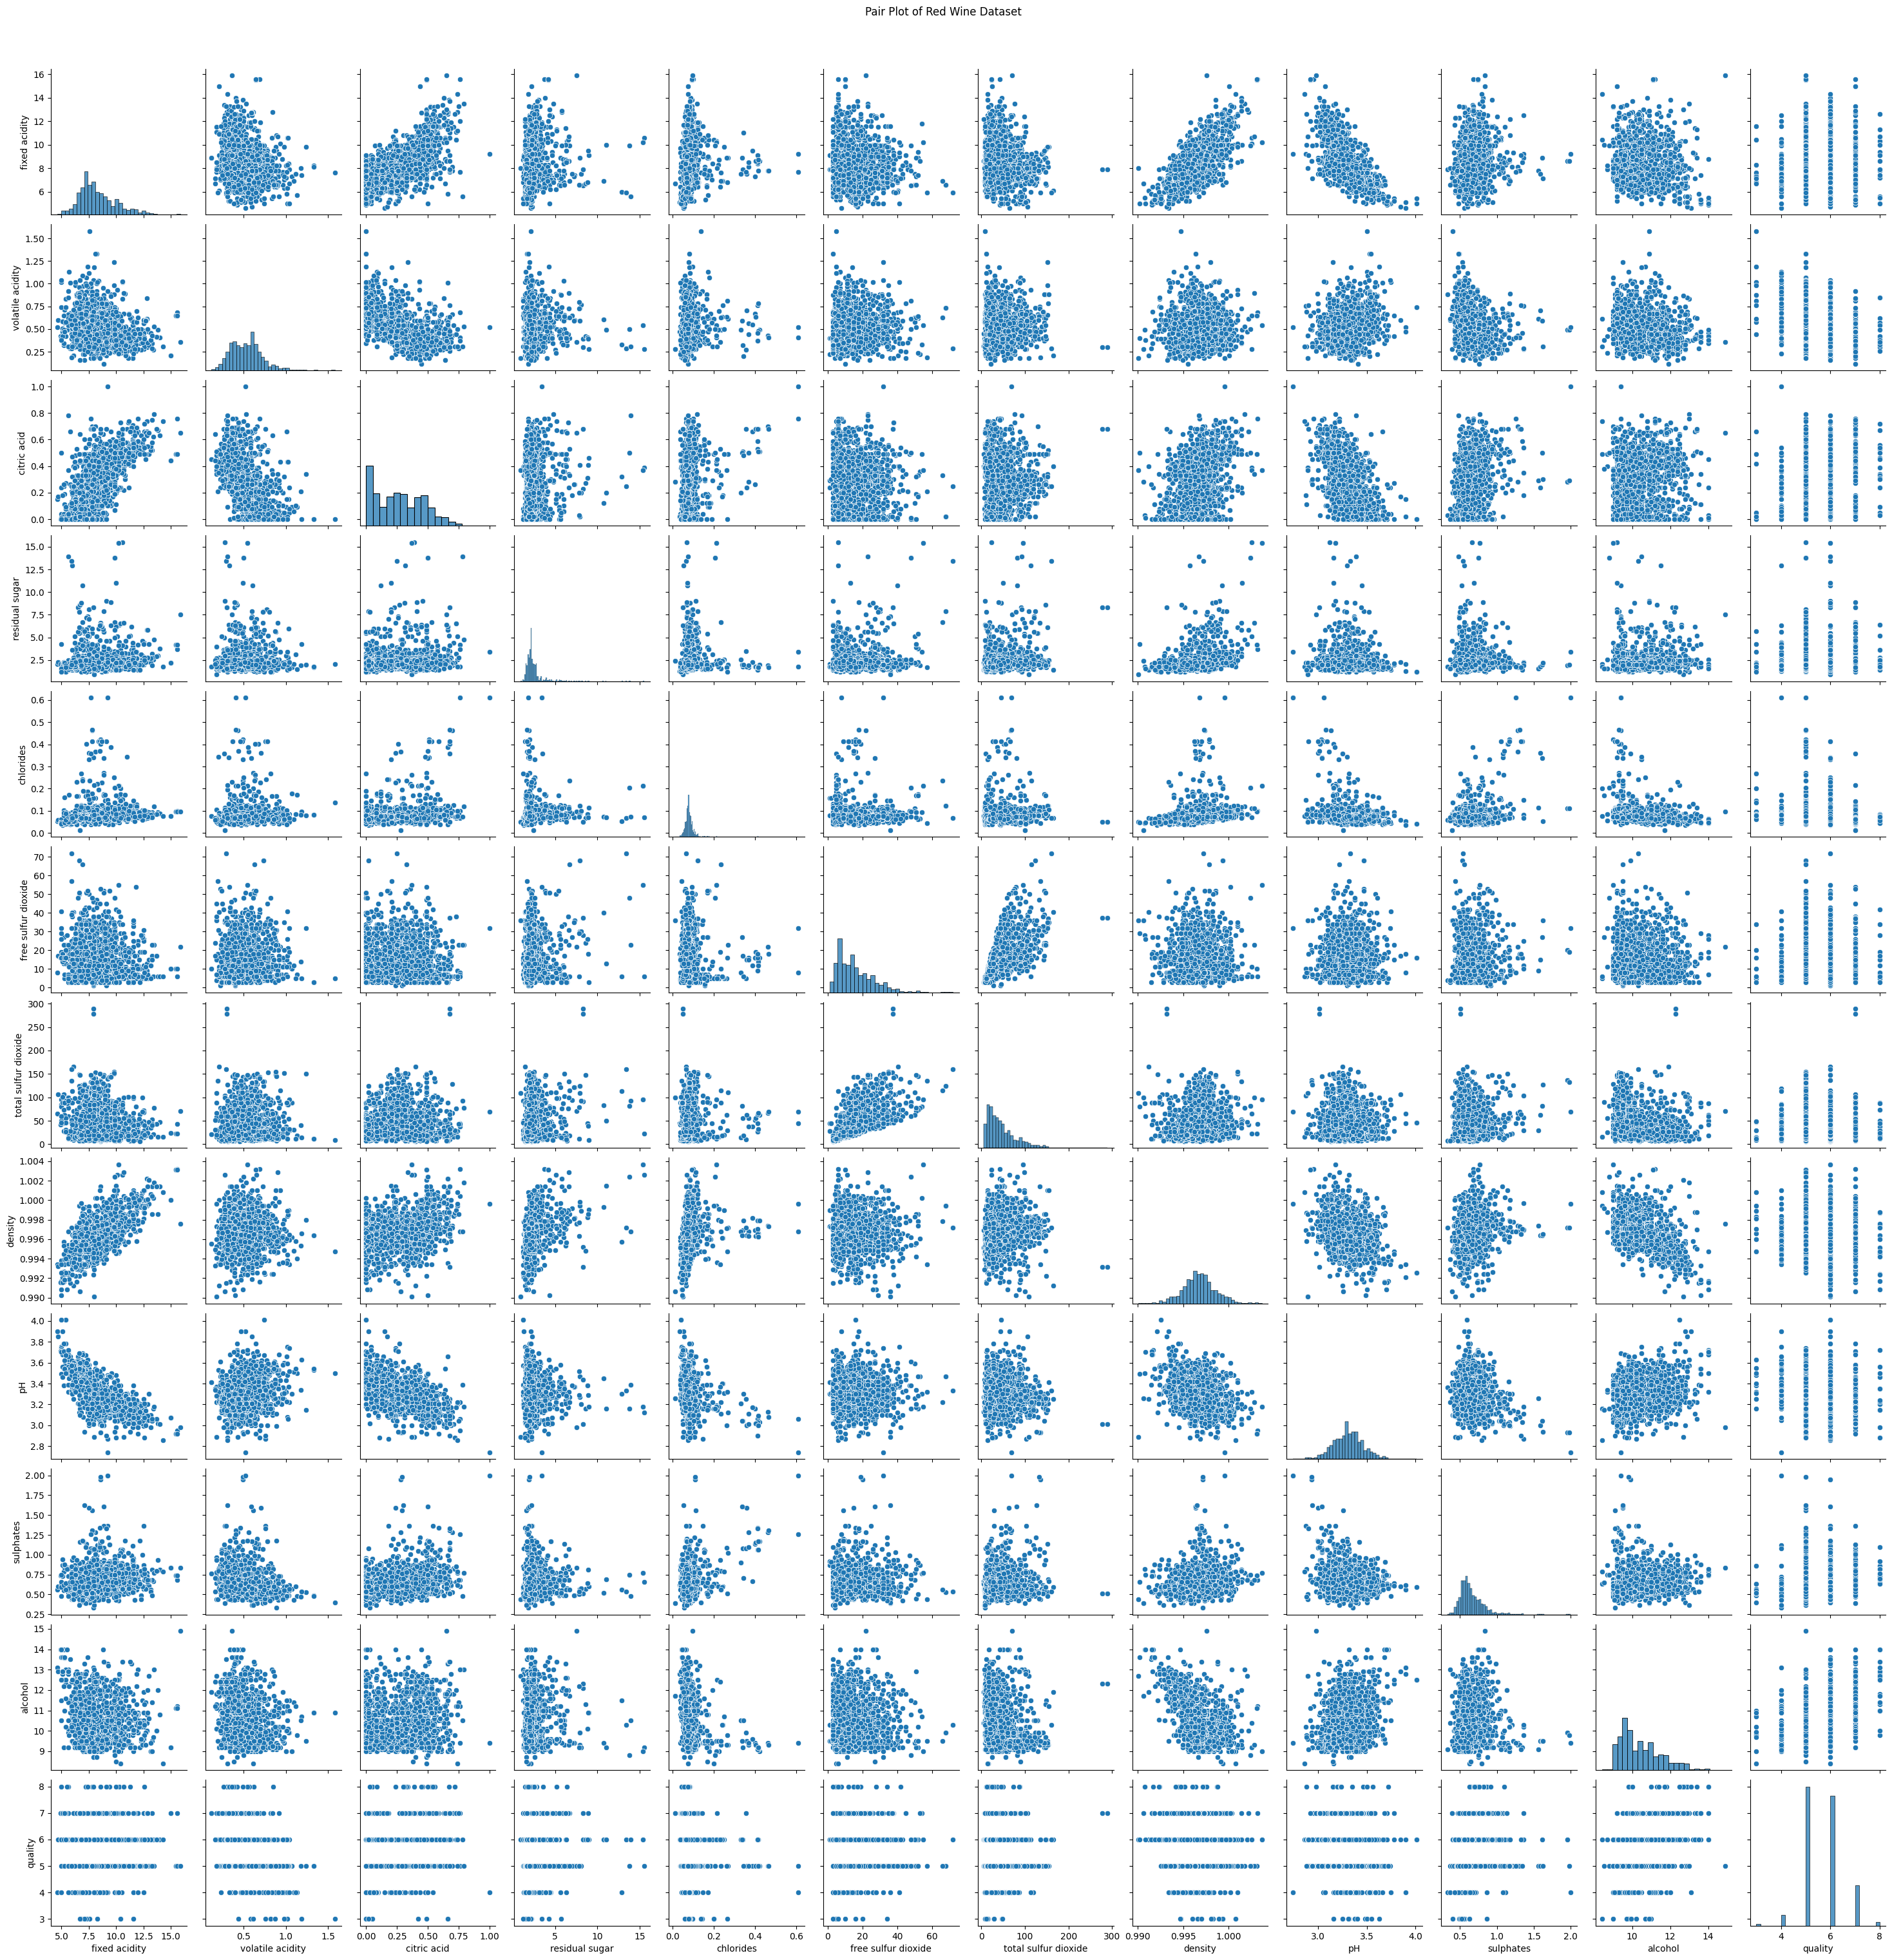

In [172]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gerar um pair plot para df_redWine
sns.pairplot(df_redWine)
plt.suptitle('Pair Plot of Red Wine Dataset', y=1.02) # Adiciona um título ao gráfico
plt.show()

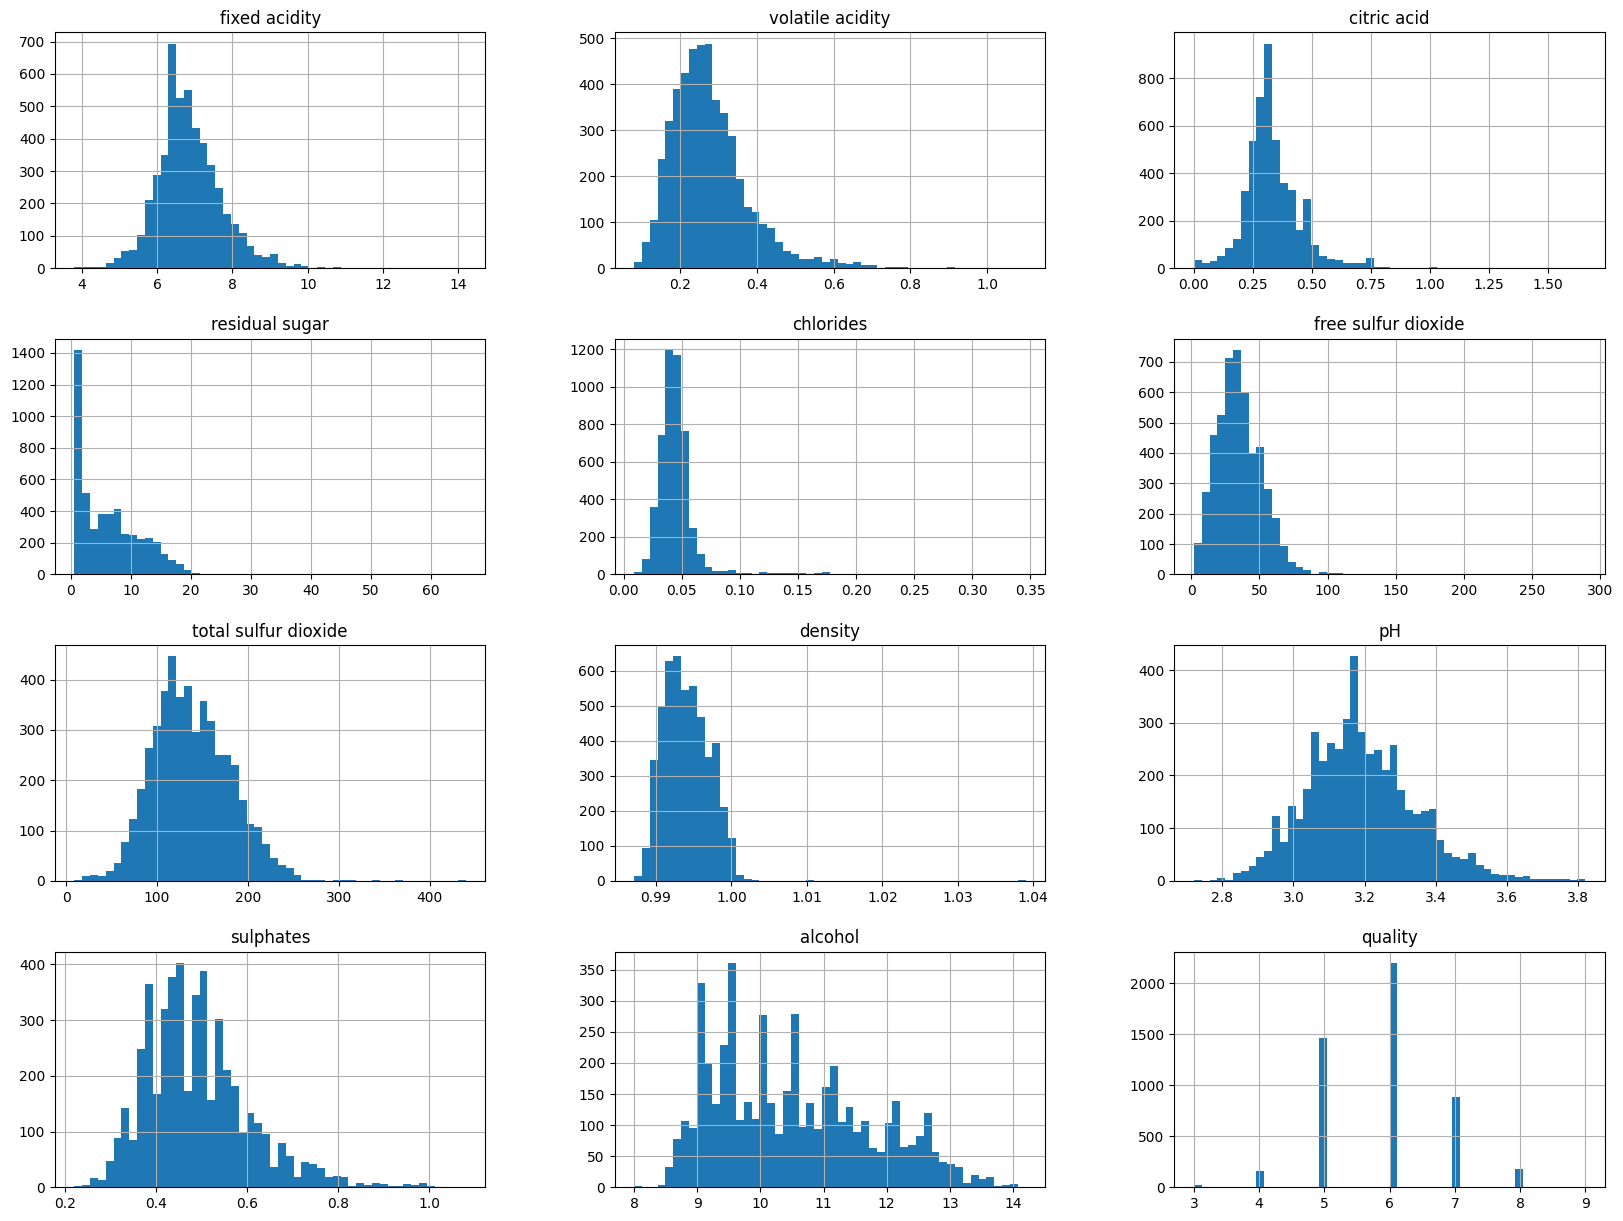

In [173]:
import matplotlib.pyplot as plt
df_whiteWine.hist(bins=50, figsize=(20,15))
plt.show()


In [174]:
df_redWine['quality'].value_counts().sort_index()

,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


In [175]:
df_whiteWine['quality'].value_counts().sort_index()

,count
quality,
3,20
4,163
5,1457
6,2198
7,880
8,175
9,5


OBRIGATÓRIO: Explicar quais features estão envolvidas e o seu respectivo target

As features são alcohol, pH,sulphates,free sulfur dioxide,citric acid, residual sugar, fixed acidity, total sulfur dioxide, chiorides,density. Por sua vez, a variável alvo é quality.

#Engenharia de Features

In [176]:
import numpy as np
import pandas as pd # Ensure pandas is imported
from sklearn.preprocessing import PolynomialFeatures

df_whiteWineTratado = df_whiteWine.copy()

# Add existing custom features
df_whiteWineTratado['relation_acidity_sugar'] = df_whiteWineTratado['citric acid'] / (df_whiteWineTratado['residual sugar'] + 1e-5)
df_whiteWineTratado['total_acidity'] = df_whiteWineTratado['fixed acidity'] + df_whiteWineTratado['volatile acidity'] + df_whiteWineTratado['citric acid']
df_whiteWineTratado['body_and_texture'] = df_whiteWineTratado['alcohol'] * df_whiteWineTratado['density']
df_whiteWineTratado['sugar_alcohol_balance'] = df_whiteWineTratado['residual sugar'] * df_whiteWineTratado['alcohol']
df_whiteWineTratado['fixed_to_volatile_acidity'] = df_whiteWineTratado['fixed acidity'] / (df_whiteWineTratado['volatile acidity'] + 1e-5)
df_whiteWineTratado['sulfur_density_load'] = df_whiteWineTratado['total sulfur dioxide'] / (df_whiteWineTratado['density'] + 1e-5)

# Add new logarithmic features
df_whiteWineTratado['log_residual_sugar'] = np.log1p(df_whiteWineTratado['residual sugar'])
df_whiteWineTratado['log_chlorides'] = np.log1p(df_whiteWineTratado['chlorides'])
df_whiteWineTratado['log_volatile_acidity'] = np.log1p(df_whiteWineTratado['volatile acidity'])

# Define base features for polynomial expansion
poly_base_features = ['alcohol', 'density', 'volatile acidity', 'total sulfur dioxide', 'fixed acidity', 'residual sugar']

# Generate polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_transformed = poly.fit_transform(df_whiteWineTratado[poly_base_features])
poly_feature_names = poly.get_feature_names_out(poly_base_features) # Use poly_base_features for naming

# Create a DataFrame for polynomial features
df_poly_features = pd.DataFrame(poly_transformed, columns=poly_feature_names, index=df_whiteWineTratado.index)

# Drop the original base features that are now represented by polynomial features
# This avoids duplicate columns when concatenating, as poly_features will contain these base features too.
df_whiteWineTratado = df_whiteWineTratado.drop(columns=poly_base_features)

# Concatenate the new polynomial features to the main DataFrame
df_whiteWineTratado = pd.concat([df_whiteWineTratado, df_poly_features], axis=1)

# Replace infinite values generated by divisions (e.g., division by zero) with NaN and then drop them
df_whiteWineTratado.replace([np.inf, -np.inf], np.nan, inplace=True)
df_whiteWineTratado.dropna(inplace=True)

In [177]:
df_whiteWineTratado.describe()

,citric acid,chlorides,free sulfur dioxide,pH,sulphates,quality,relation_acidity_sugar,total_acidity,body_and_texture,sugar_alcohol_balance,...,volatile acidity^2,volatile acidity total sulfur dioxide,volatile acidity fixed acidity,volatile acidity residual sugar,total sulfur dioxide^2,total sulfur dioxide fixed acidity,total sulfur dioxide residual sugar,fixed acidity^2,fixed acidity residual sugar,residual sugar^2
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,...,4898.000000,4898.00000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,0.334192,0.045772,35.308085,3.188267,0.489847,5.877909,0.112927,7.467220,10.448598,64.388877,...,0.087576,38.87990,1.905354,1.811213,20949.388271,951.698275,970.833999,47.700082,44.192736,66.570702
std,0.121020,0.021848,17.007137,0.151001,0.114126,0.885639,0.113972,0.887962,1.197932,48.360894,...,0.075325,19.81085,0.737947,1.811280,12777.811612,326.927062,910.736828,12.108910,36.226892,106.823729
min,0.000000,0.009000,2.000000,2.720000,0.220000,3.000000,0.000000,4.130000,7.946560,6.360000,...,0.006400,3.12000,0.520000,0.098000,81.000000,42.300000,9.000000,14.440000,3.570000,0.360000
25%,0.270000,0.036000,23.000000,3.090000,0.410000,5.000000,0.032326,6.890000,9.434403,19.040000,...,0.044100,25.20000,1.428000,0.465000,11664.000000,715.000000,213.700000,39.690000,12.000000,2.890000
50%,0.320000,0.043000,34.000000,3.180000,0.470000,6.000000,0.060319,7.405000,10.320960,57.625000,...,0.067600,35.19000,1.768000,1.378500,17956.000000,904.400000,644.900000,46.240000,34.990000,27.040000
75%,0.390000,0.050000,46.000000,3.280000,0.550000,6.000000,0.169999,7.960000,11.293837,99.510000,...,0.102400,48.49125,2.232000,2.641000,27889.000000,1165.750000,1531.150000,53.290000,68.295000,98.010000
max,1.660000,0.346000,289.000000,3.820000,1.080000,9.000000,0.924988,14.960000,14.026618,769.860000,...,1.210000,201.57500,9.949500,63.497000,193600.000000,3151.900000,10528.000000,201.640000,513.240000,4329.640000


In [178]:
corr_matrix=df_whiteWineTratado.corr()
corr_matrix['quality'].sort_values(ascending=False)

,quality
quality,1.000000
alcohol^2,0.437922
alcohol density,0.436106
body_and_texture,0.436106
alcohol,0.435575
alcohol fixed acidity,0.220686
fixed_to_volatile_acidity,0.144205
pH,0.099427
sulphates,0.053678
relation_acidity_sugar,0.027762


3. Dividir os dados em conjunto de treinamento e teste e fazer a regressão com pelo menos três modelos diferentes

In [179]:
# Define X by dropping only the target variable 'quality'
# All other columns in df_whiteWineTratado should now be treated as features,
# including the new custom, log-transformed, and polynomial features.
X = df_whiteWineTratado.drop(columns=['quality'])
y = df_whiteWineTratado['quality']

In [180]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42,stratify=y
)

# Regressão Linear

In [181]:
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Padronize os dados de treino e teste
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lin = LinearRegression()

scores = cross_val_score(
    model_lin, X_train_scaled, y_train, cv=5, scoring='r2'
)

model_lin.fit(X_train_scaled, y_train)

y_pred_lin = model_lin.predict(X_test_scaled)

coeficientes = np.abs(model_lin.coef_)

importancias_lineares = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': coeficientes
}).sort_values(by='Importancia', ascending=False)

print(importancias_lineares)

                                 Variavel  Importancia
17                   total sulfur dioxide  9605.441297
28           density total sulfur dioxide  4853.239250
10                    sulfur_density_load  4753.011142
26                              density^2   174.012942
15                                density   172.035950
30                 density residual sugar    68.371333
19                         residual sugar    67.150659
27               density volatile acidity    26.517883
29                  density fixed acidity    21.404411
16                       volatile acidity    18.697756
14                                alcohol    16.967909
6                           total_acidity    11.222880
18                          fixed acidity     9.850551
7                        body_and_texture     8.812799
21                        alcohol density     8.812799
13                   log_volatile_acidity     6.194982
31                     volatile acidity^2     1.521560
0         

# Arvore de Decisão

In [182]:
X = df_whiteWineTratado.drop(columns=['quality','alcohol','density'])
y = df_whiteWineTratado['quality']

In [183]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42,stratify=y
)

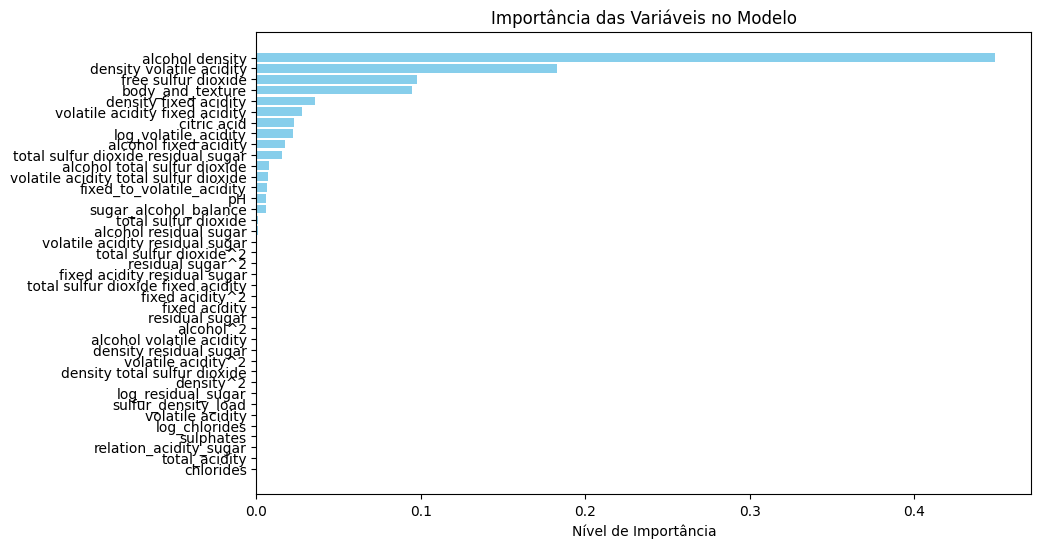

In [184]:
from sklearn.tree import DecisionTreeRegressor

model_dtr = DecisionTreeRegressor(random_state=42, max_depth=5)
scores = cross_val_score(
    model_dtr, X_train, y_train, cv=5, scoring='r2'
)
model_dtr.fit(X_train, y_train)

y_pred_dtr = model_dtr.predict(X_test)

importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': model_dtr.feature_importances_
})


importancias = importancias.sort_values(by='Importancia', ascending=True)

# 5. Plote um gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variavel'], importancias['Importancia'], color='skyblue')
plt.title('Importância das Variáveis no Modelo')
plt.xlabel('Nível de Importância')
plt.show()

# Random Forest

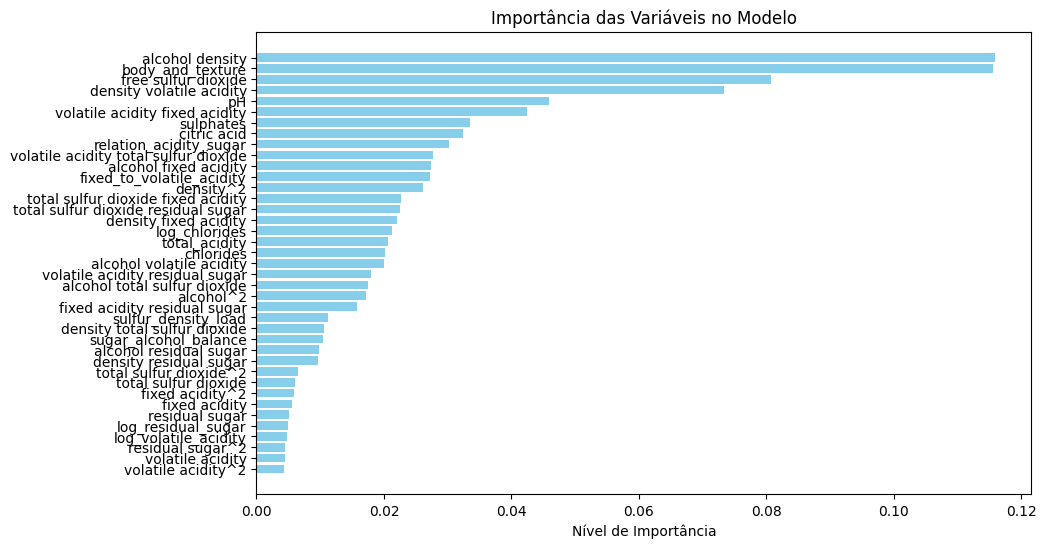

In [185]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(
    model_rf, X_train, y_train, cv=5, scoring='r2'
)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': model_rf.feature_importances_
})


importancias = importancias.sort_values(by='Importancia', ascending=True)

# 5. Plote um gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variavel'], importancias['Importancia'], color='skyblue')
plt.title('Importância das Variáveis no Modelo')
plt.xlabel('Nível de Importância')
plt.show()

# Suport Vector Regressor (SVR)

In [186]:
from sklearn.svm import SVR

model_svr = SVR(kernel='rbf', C=100, gamma=0.1)

scores = cross_val_score(
    model_svr, X_train, y_train, cv=5, scoring='r2'
)

model_svr.fit(X_train, y_train)

y_pred_svr = model_svr.predict(X_test)

# XGBoost Regressor

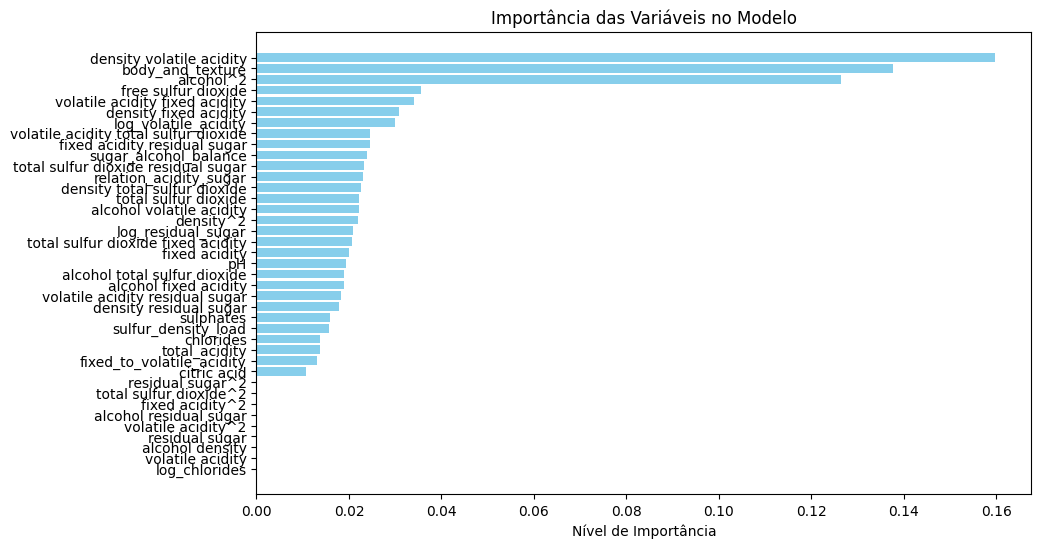

In [187]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

scores = cross_val_score(
    model_xgb, X_train, y_train, cv=5, scoring='r2'
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

# 3. Extraia a importância e crie um DataFrame para visualizar
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': model_xgb.feature_importances_
})

# 4. Ordene da maior para a menor importância
importancias = importancias.sort_values(by='Importancia', ascending=True)

# 5. Plote um gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variavel'], importancias['Importancia'], color='skyblue')
plt.title('Importância das Variáveis no Modelo')
plt.xlabel('Nível de Importância')
plt.show()

4. Metricas de desempenho

(Usar as métricas de desempenho para comparar os resultados)

In [188]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def print_metrics(y_true, y_pred, model_name=""):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    print(f"{model_name}:")
    print(f"  MSE = {mse:.4f}")
    print(f"  MAE = {mae:.4f}")
    print(f"  R²  = {r2:.4f}")
    print("-"*30)

# Métricas para cada modelo
print_metrics(y_test, y_pred_lin, "LinearRegression")
print_metrics(y_test, y_pred_dtr, "DecisionTreeRegressor")
print_metrics(y_test, y_pred_rf,  "RandomForestRegressor")
print_metrics(y_test, y_pred_svr, "SVR")
print_metrics(y_test, y_pred_xgb, "XGBRegressor")



LinearRegression:
  MSE = 0.5528
  MAE = 0.5824
  R²  = 0.2959
------------------------------
DecisionTreeRegressor:
  MSE = 0.5449
  MAE = 0.5737
  R²  = 0.3059
------------------------------
RandomForestRegressor:
  MSE = 0.3849
  MAE = 0.4490
  R²  = 0.5097
------------------------------
SVR:
  MSE = 0.5657
  MAE = 0.5221
  R²  = 0.2794
------------------------------
XGBRegressor:
  MSE = 0.4291
  MAE = 0.4935
  R²  = 0.4534
------------------------------


5. Conclusão

Qual dos modelos conseguiu o melhor desempenho?